In [1]:
import sys, os
sys.path.insert(0, '../../utils')

In [2]:
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from connectome_types import DATA_BASE_PATH
from neuron_custom_features import calc_spines_features, calc_basic_degrree_features
from spines_utils import filter_valid_neuron_w_spines, split_syn_mat_by_type_four
from utils import load_synapses_position_transformed, load_neurons_table
from matplotlib.ticker import PercentFormatter
from spine_pref_utils import build_subnet_spine_ratio_df, mean_input_outdegree
from stats_corr import add_reg_line, p_to_stars

In [3]:
subnetworks = ['0.5', '0.25', '0.125', '0.0625']
subnetworks_names = [f'micro_column_network/subnetworks/{s}' for s in subnetworks]
networks = ['micro_column_network']
networks.extend(subnetworks_names)

network_names = ['Micro-column network', 'Subnetwork 0.5', 'Subnetwork 0.25',
                 'Subnetwork 0.125', 'Subnetwork 0.0625']
cmap = sns.color_palette(["#666666", "#9D174D", "#DB2777", "#F472B6", "#FBCFE8"],
                         n_colors=len(network_names))

In [4]:
dfs = []; ex_dfs = []; inh_dfs = []
dfs_EE = []

for network_name in tqdm(networks):
    if network_name == 'micro_column_network':
        neuronds_df = load_neurons_table()
    else:
        neuronds_df = pd.read_csv(f'{DATA_BASE_PATH}/{network_name}/connectome_neurons.csv', index_col=0)

    calc_basic_degrree_features(neuronds_df)
    syn_df = load_synapses_position_transformed(
        base_syn_table_path=f'{DATA_BASE_PATH}/{network_name}/connectome_synapses.csv')

    df, syn_with_tags = calc_spines_features(
        neuronds_df, syn_df,
        spine_table=f'{DATA_BASE_PATH}/{network_name}/spine_table.csv',
        spine_table_outgoing=f'{DATA_BASE_PATH}/{network_name}/spine_table_outgoing.csv')

    df, filtered_syn_mat, filtered_bin_mat, filtered_mapping, filtered_reverse_mapping, ex_neurons, inh_neurons = filter_valid_neuron_w_spines(df)
    neuron_clf_type = df[['root_id', 'clf_type']].set_index('root_id').to_dict(orient='index')

    EE, EI, IE, II, ex_idx, inh_idx = split_syn_mat_by_type_four(filtered_bin_mat, filtered_mapping, neuron_clf_type)
    df_EE = build_subnet_spine_ratio_df(EE, ex_idx, ex_idx, filtered_mapping, 'E', 'E', syn_with_tags, ex_neurons)
    dfs_EE.append(df_EE)

    REAL_BLOCKS = {'EE': EE, 'EI': EI, 'IE': IE, 'II': II}
    BLOCK_COL_IDX = {'EE': ex_idx, 'IE': ex_idx, 'EI': inh_idx, 'II': inh_idx}
    all_idx = sorted(filtered_mapping.keys())
    ex_od_df, inh_od_df = mean_input_outdegree(
        REAL_BLOCKS, BLOCK_COL_IDX, filtered_mapping, df,
        full_mat=filtered_bin_mat, all_idx=all_idx)

    ex_neurons = ex_neurons.merge(
        ex_od_df[['root_id', 'mean_input_outdegree_EE', 'mean_input_outdegree_IE', 'mean_input_outdegree_full']],
        on='root_id', how='left')
    inh_neurons = inh_neurons.merge(
        inh_od_df[['root_id', 'mean_input_outdegree_EI', 'mean_input_outdegree_II', 'mean_input_outdegree_full']],
        on='root_id', how='left')

    ex_neurons = ex_neurons.merge(
        df_EE[['root_id', 'outgoing_spine_ratio']], on='root_id', how='left')

    dfs.append(df)
    ex_dfs.append(ex_neurons)
    inh_dfs.append(inh_neurons)

  0%|          | 0/5 [00:00<?, ?it/s]

connectome neurons table:  1351
valid neurons w position: 1351
spine table incoming size (4567647, 4)
spine table outgoing size (819832, 4)
neurons: 1351
synapses with tags: 145356


100%|██████████| 1351/1351 [00:14<00:00, 90.71it/s]


Filtering neurons with valid spine data...
Remaining neurons after filtering: 1298
fixing networks
Filtering: Reducing matrix from 1351 to 1298 neurons.


 20%|██        | 1/5 [00:18<01:15, 18.95s/it]

...

spine table incoming size (852218, 5)
spine table outgoing size (146256, 5)
neurons: 245
synapses with tags: 5166


 80%|████████  | 4/5 [00:40<00:07,  7.68s/it]

Filtering neurons with valid spine data...
Remaining neurons after filtering: 236
fixing networks
Filtering: Reducing matrix from 1351 to 236 neurons.
spine table incoming size (505550, 5)
spine table outgoing size (86682, 5)
neurons: 141
synapses with tags: 1881


100%|██████████| 5/5 [00:41<00:00,  8.37s/it]

Filtering neurons with valid spine data...
Remaining neurons after filtering: 138
fixing networks
Filtering: Reducing matrix from 1351 to 138 neurons.


In [5]:
plt.rcParams['font.size'] = 16
plt.rcParams['font.family'] = 'Arial'

purples = ['#C4B5FD', '#A17EFC', '#7C3AED']
greens = ['#6EE7B7', '#34D399', '#10B981', '#059669', '#047857']
scatter_palette = {
    '23P': purples[2], '4P': purples[1], '5P-IT': purples[0],
    '5P-NP': greens[4], '5P-PT': greens[3], '6P-CT': greens[2],
    '6P-IT': greens[1], '6P-U': greens[0],
}

ex_dfs_sorted = []
for df_ee in ex_dfs:
    sorted_df = df_ee.sort_values('cell_type')
    ignore_cell_type = ['WM-P', 'Unsure E']
    sorted_df = sorted_df[~sorted_df['cell_type'].isin(ignore_cell_type)]
    if hasattr(sorted_df['cell_type'], 'cat'):
        sorted_df['cell_type'] = sorted_df['cell_type'].cat.remove_unused_categories()
    ex_dfs_sorted.append(sorted_df)

R=0.57 R^2: 0.33 slope: 23.56 intercept: 21.29, p=p=3.6e-100
R=0.54 R^2: 0.29 slope: 16.56 intercept: 16.46, p=p=1.7e-58
R=0.42 R^2: 0.18 slope: 7.09 intercept: 10.50, p=p=5.3e-18
R=0.27 R^2: 0.07 slope: 2.76 intercept: 6.84, p=p=7.1e-05
R=0.12 R^2: 0.01 slope: 0.74 intercept: 4.69, p=p=0.242


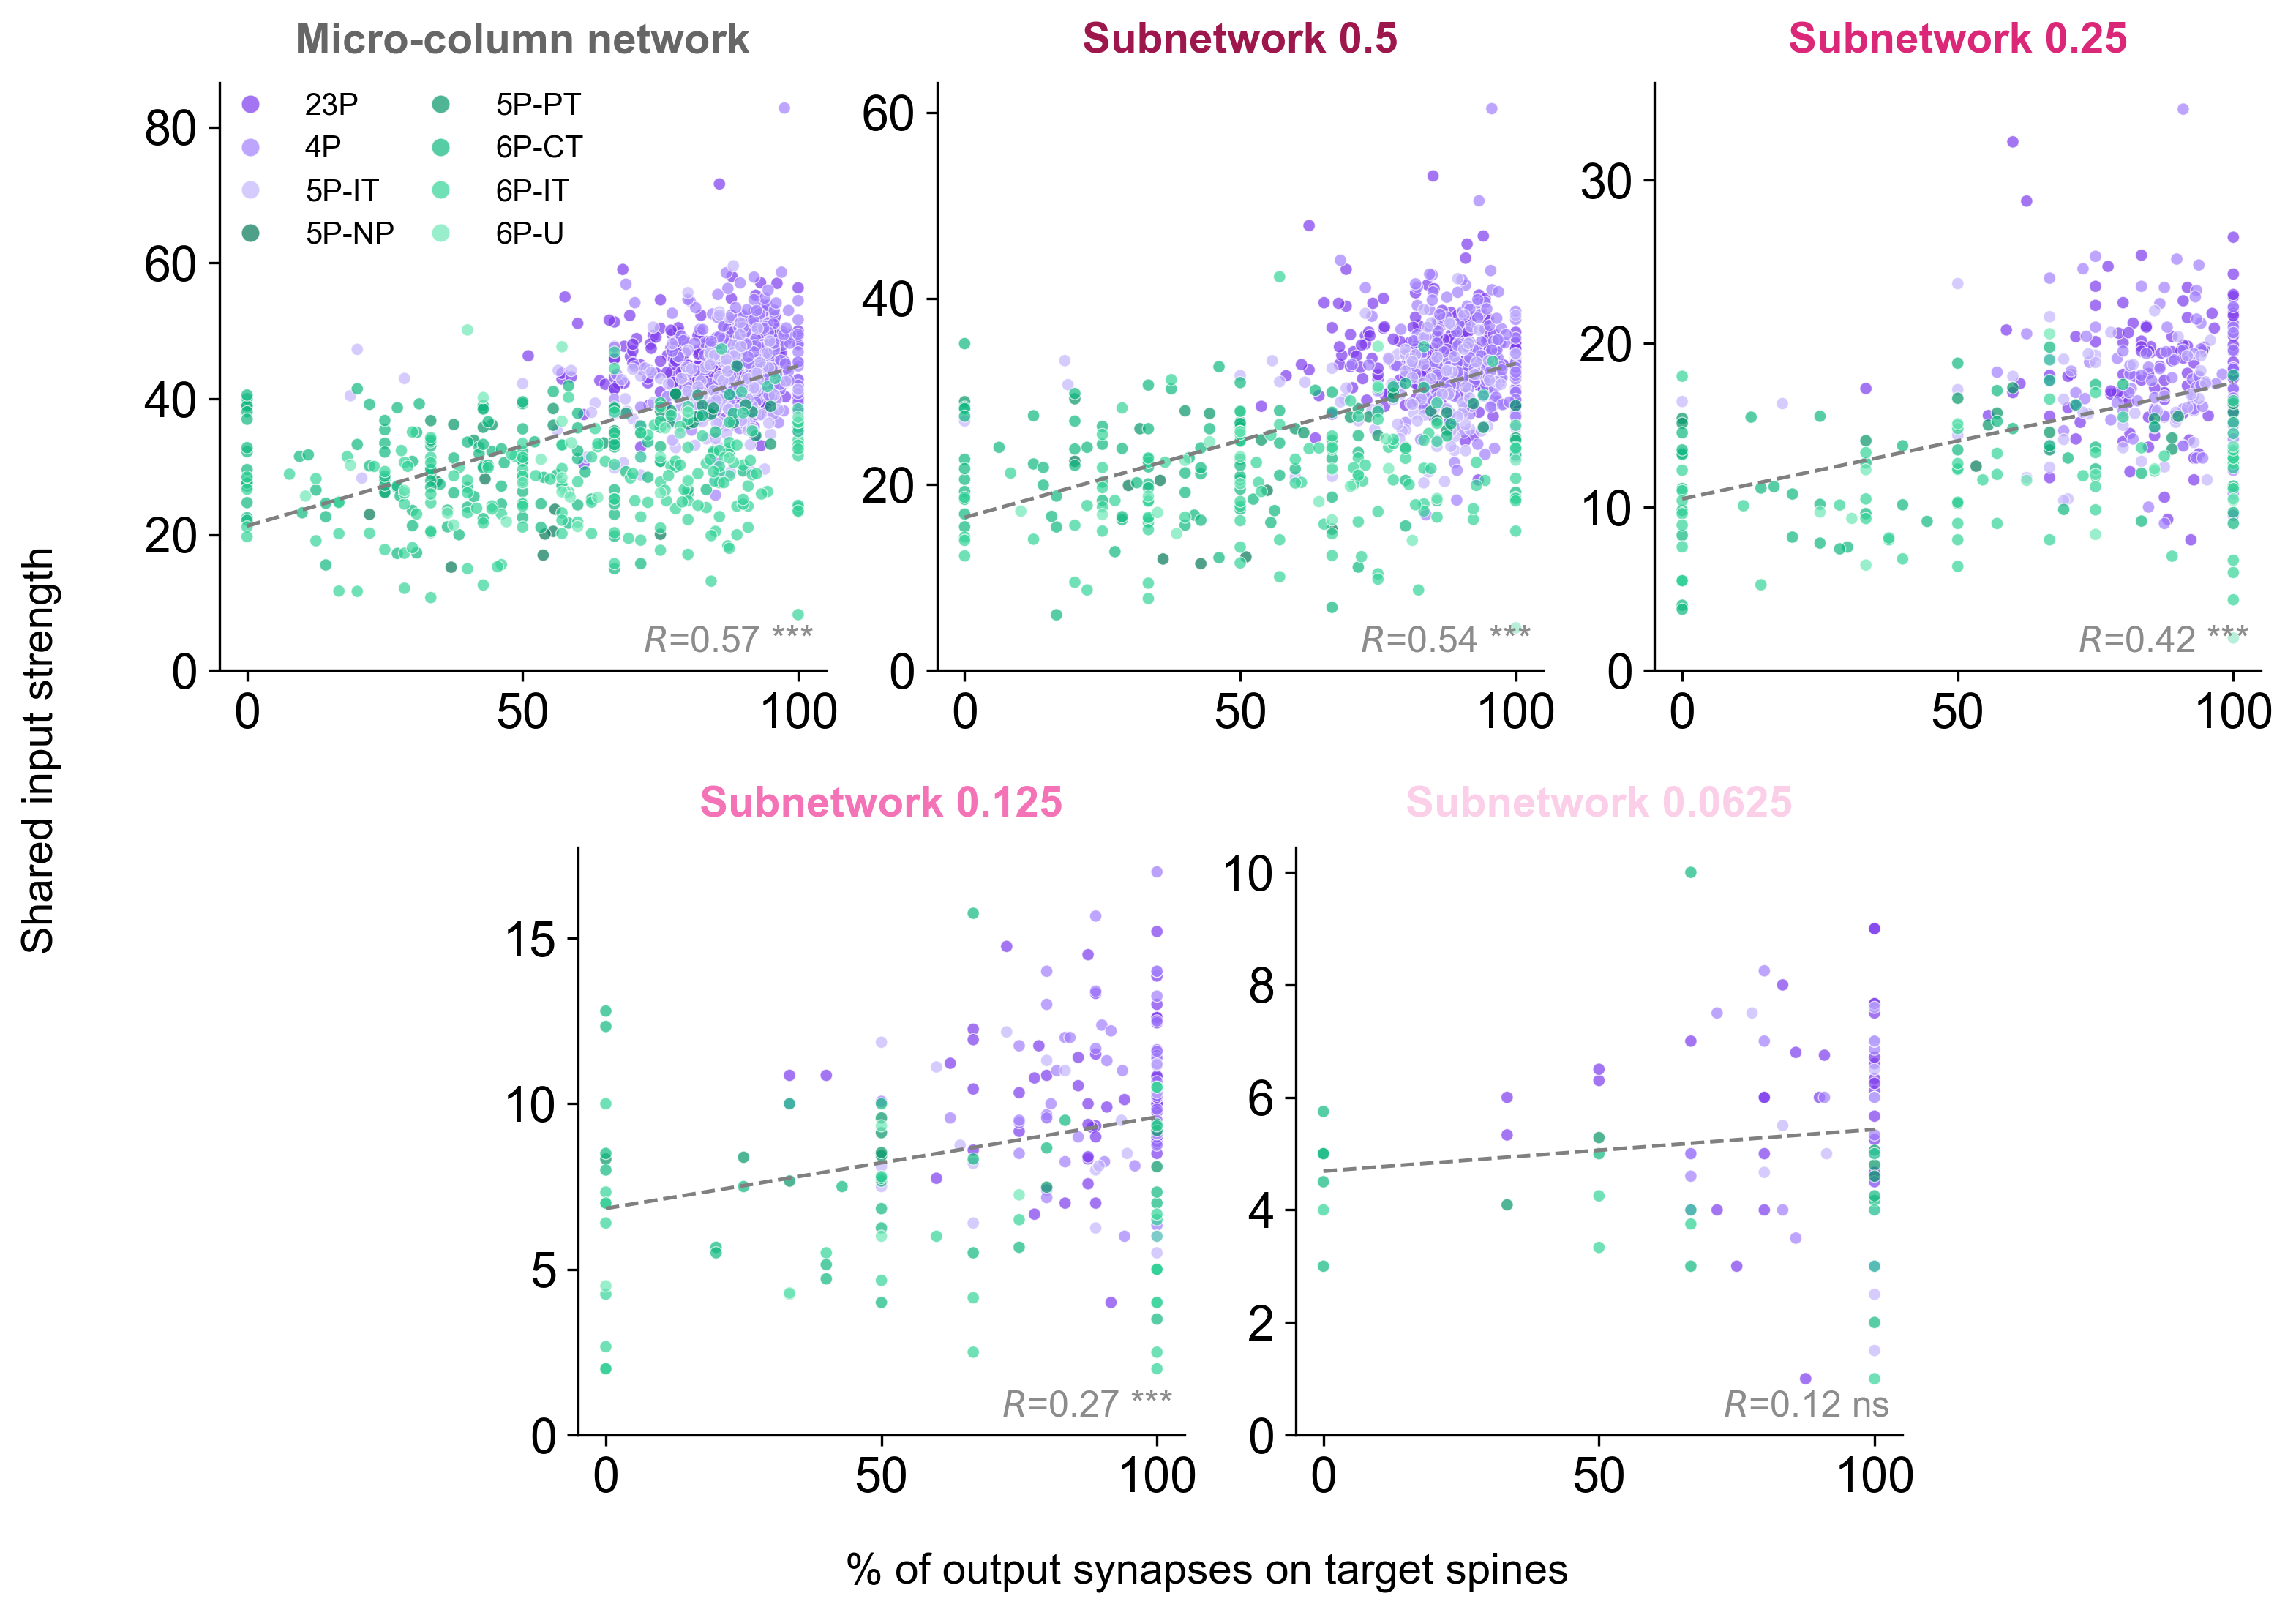

In [6]:
fig = plt.figure(figsize=(12, 8), dpi=300)
gs = fig.add_gridspec(2, 6, hspace=0.3, wspace=0.45)

ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes = [ax1, ax2, ax3, ax4, ax5]

for idx, df_ee in enumerate(ex_dfs):
    ax = axes[idx]
    df_ee_sorted = ex_dfs_sorted[idx]
    x = df_ee['outgoing_spine_ratio']
    y = df_ee['mean_input_outdegree_EE']
    valid_mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isinf(x) & ~np.isinf(y)
    x = x[valid_mask]
    y = y[valid_mask]

    sns.scatterplot(data=df_ee_sorted, x='outgoing_spine_ratio', y='mean_input_outdegree_EE',
                    s=16, alpha=0.7, ax=ax, hue='cell_type', palette=scatter_palette, legend=True)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.legend_.remove()
    ax.set_title(network_names[idx], color=cmap[idx], fontsize=14, fontweight='bold', y=1.02)
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0, symbol=''))

    add_reg_line(df_ee['outgoing_spine_ratio'], df_ee['mean_input_outdegree_EE'],
                 ax=ax, color='gray', reg_text_font_size=12,
                 linestyle='--', linewidth=1.2, add_reg_text='r_only')
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(bottom=0)

fig.supxlabel('% of output synapses on target spines', y=0.02, fontsize=14)
fig.supylabel('Shared input strength', x=0.05, fontsize=14)
axes[0].legend(title='', loc='upper left', frameon=False, markerscale=1.5,
               columnspacing=.5, fontsize=10, ncol=2, bbox_to_anchor=(-0.045, 1.03))

plt.savefig('fig_s13.pdf', format='pdf', bbox_inches='tight')